In [1]:
import pandas as pd
import numpy as np
import re 
from IPython.display import display, HTML

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV 
from sklearn.metrics import classification_report, confusion_matrix, f1_score, hamming_loss, jaccard_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from xgboost import XGBClassifier
from sklearn.multioutput import MultiOutputClassifier, ClassifierChain
from sklearn.calibration import CalibratedClassifierCV
from scipy.stats import entropy

import shap

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)

data= pd.read_csv("anti_total.csv", index_col=False)

In [3]:
start_index = data.columns.get_loc('Acyclovir')
end_index = data.columns.get_loc('tenofovir/emtricitabine/rilpivirine')

In [4]:
abx_cols = data.columns[start_index:end_index+1]
col_sum = data[abx_cols].sum()

In [5]:
abx_cols = data.columns[start_index:end_index+1]
col_sum = data[abx_cols].sum()

In [6]:
final_cols = col_sum[col_sum >= 400].index.tolist()
base_cols = [c for c in data.columns if c not in abx_cols]
data_filter = data[base_cols + final_cols]

In [7]:
data_filter[final_cols].sum().sort_values(ascending=False)

Amoxicillin/Clavulanic acid    5515.0
Flomoxef                       5196.0
Cefazolin                      2371.0
Cefixime                       2166.0
Ciprofloxacin                  2071.0
Azithromycin                   2053.0
Cefuroxime                     1691.0
Piperacillin/Tazobactam        1511.0
Cefoperazone/sulbactam         1412.0
Peramivir                      1119.0
Baloxavir marboxil             1085.0
Metronidazole                  1020.0
Cefadroxil                      918.0
Oseltamivir                     835.0
Levofloxacin                    720.0
Clindamycin                     624.0
Gentamicin                      623.0
Ceftriaxone                     610.0
Cephalexin                      517.0
Ampicillin                      423.0
dtype: float64

In [8]:
all_site_cols = [
    'INFECTIONSITE1', 'INFECTIONSITE2', 'INFECTIONSITE3',
    'INFECTIONSITE4', 'INFECTIONSITE5', 'INFECTIONSITE9', 
    'OTHERINFECTIONSITE_flag'
]

temp_df = data_filter[all_site_cols].copy().astype(str).apply(lambda x: x.str.strip())
temp_df = temp_df.replace(['', 'nan', 'None', 'nan.0'], '0')

temp_df = temp_df.astype(float)

has_site_mask = (temp_df > 0).any(axis=1)

site_samples = data[has_site_mask].copy()

print(f"原始樣本數: {len(data)}")
print(f"至少標註一個部位的樣本數: {len(site_samples)}")
print(f"被排除掉的『全空/全0』樣本數: {len(data) - len(site_samples)}")


原始樣本數: 27968
至少標註一個部位的樣本數: 11880
被排除掉的『全空/全0』樣本數: 16088


In [9]:
len(site_samples), len(site_samples['ACCOUNTNO'])

(11880, 11880)

In [10]:
site_samples['Clindamycin'].sum(), site_samples['Gentamicin'].sum()

(379.0, 201.0)

In [11]:
roomno_mapping = {'A': '1', 'C': '2', 'D': '3', 'E': '4', 'H': '5', 'K': '6'}
site_samples['ROOMNO'] = site_samples['ROOMNO'].map(roomno_mapping)          

site_samples['SEX'] = site_samples['SEX'].map({'M': 1, 'F': 0})

yn_cols = [
    'ISSEPSIS0', 'FEVER', 'DM', 'CARDIOVASCULAR', 
    'RESPIRATORY', 'CNS', 'CANCER', 'LIVER', 'KIDNEY', 'AUTOIMMUNE'
]

for col in yn_cols:
    site_samples[col] = site_samples[col].map({'Y': 1, 'N': 0})

In [12]:
feature_cols = list(set(site_samples.columns) - set(abx_cols))
X = site_samples[feature_cols]
y = site_samples[final_cols]

In [13]:
X.shape, y.shape

((11880, 68), (11880, 20))

In [14]:
X = X.drop(columns=['ACCOUNTNO','ROOMNO', 'INTIME', 'Influenza Virus A level', 'FIRST_ORDERTIME', 'ISSEPSIS0'])
y = y.drop(columns=['Peramivir', 'Baloxavir marboxil', 'Oseltamivir', 'Cephalexin', 'Cefadroxil'])
                    #'Amoxicillin', 'Doxycycline', 'Acyclovir', 'Valaciclovir', 'Tenofovir alafenamide', 'Ceftazidime'])# 去掉抗病毒的藥(前3) 

In [15]:
X.columns

Index(['VITALSIGNSSPO2', 'Absolute Neutrophil count', 'CHECKITEM27SCORE',
       'GPT', 'Na', 'LIVER', 'VITALSIGNSPR', 'WBC', 'KIDNEY', 'Lymphocyte',
       'HST', 'CNS', 'INFECTIONSITE1', 'MAP', 'CRP', 'VITALSIGNSBT',
       'CHECKITEM30SCORE', 'Leukocyte level', 'T.Bilirubin', 'Nitrite level',
       'PT', 'PH', 'APTT', 'CHECKITEM29SCORE', 'FEVER', 'CHECKITEM31SCORE',
       'AUTOIMMUNE', 'Hb', 'CANCER', 'BE(ecf)', 'Creatinine', 'DM',
       'CHECKITEM28A', 'K', 'INFECTIONSITE2', 'Ht', 'CHECKITEM27',
       'OTHERINFECTIONSITE_flag', 'PLT', 'INFECTIONSITE9',
       'Microscopic RBC level', 'CARDIOVASCULAR', 'Microscopic WBC level',
       'VITALSIGNSDBP', 'CHECKITEM28SCORE', 'CHECKITEM32SCORE', 'SEX',
       'INFECTIONSITE4', 'VITALSIGNSGCS', 'Bacteria level', 'RESPIRATORY',
       'INFECTIONSITE5', 'INFECTIONSITE3', 'Neutrophil Seg.', 'HCO3',
       'StayTime_hours', 'PCO2', 'INR', 'AGE', 'INJURELEVEL', 'O2 SAT',
       'VITALSIGNSRR'],
      dtype='object')

In [16]:
y[y.columns].sum().sort_values(ascending=False)

Flomoxef                       5190.0
Amoxicillin/Clavulanic acid    1581.0
Piperacillin/Tazobactam        1509.0
Cefoperazone/sulbactam         1411.0
Metronidazole                   916.0
Ciprofloxacin                   872.0
Cefixime                        851.0
Azithromycin                    695.0
Ceftriaxone                     609.0
Cefazolin                       589.0
Levofloxacin                    501.0
Cefuroxime                      497.0
Clindamycin                     379.0
Gentamicin                      201.0
Ampicillin                       88.0
dtype: float64

In [17]:
####################### Missing 70~80% #######################

# 檢驗

X['Leukocyte level_flag'] = (
     X['Leukocyte level'].fillna('').str.strip().ne('').astype(int))

X['Nitrite level_flag'] = (
     X['Nitrite level'].fillna('').str.strip().ne('').astype(int))

X['Bacteria level_flag'] = (
     X['Bacteria level'].fillna('').str.strip().ne('').astype(int))

X['Microscopic RBC level_flag'] = (
     X['Microscopic RBC level'].fillna('').str.strip().ne('').astype(int))

X['Microscopic WBC level_flag'] = (
     X['Microscopic WBC level'].fillna('').str.strip().ne('').astype(int))

X['PH_flag'] = (
     X['Microscopic RBC level'].fillna('').str.strip().ne('').astype(int))



# 計分

X['CHECKITEM29SCORE_flag'] = (
     X['CHECKITEM29SCORE'].fillna('').str.strip().ne('').astype(int))

X['CHECKITEM30SCORE_flag'] = (
     X['CHECKITEM30SCORE'].fillna('').str.strip().ne('').astype(int))


####################### Missing > 80% #######################

# 檢驗

X['HST_flag'] = (
     X['HST'].fillna('').str.strip().ne('').astype(int))

X['T.Bilirubin_flag'] = (
     X['T.Bilirubin'].fillna('').str.strip().ne('').astype(int))

X['PT_flag'] = (
     X['PT'].fillna('').str.strip().ne('').astype(int))

X['HST_flag'] = (
     X['HST'].fillna('').str.strip().ne('').astype(int))

X['INR_flag'] = (
     X['INR'].fillna('').str.strip().ne('').astype(int))

X['APTT_flag'] = (
     X['APTT'].fillna('').str.strip().ne('').astype(int))

X['PCO2_flag'] = (
     X['PCO2'].fillna('').str.strip().ne('').astype(int))

X['HCO3_flag'] = (
     X['HCO3'].fillna('').str.strip().ne('').astype(int))


X['BE(ecf)_flag'] = (
     X['BE(ecf)'].fillna('').str.strip().ne('').astype(int))

X['O2 SAT_flag'] = (
     X['O2 SAT'].fillna('').str.strip().ne('').astype(int))

# 計分

X['CHECKITEM28A_flag'] = (
     X['CHECKITEM28A'].fillna('').str.strip().ne('').astype(int))

X['CHECKITEM27_flag'] = (
     X['CHECKITEM27'].fillna('').str.strip().ne('').astype(int))

X['CHECKITEM27SCORE_flag'] = (
     X['CHECKITEM27SCORE'].fillna('').str.strip().ne('').astype(int))

X['CHECKITEM28SCORE_flag'] = (
     X['CHECKITEM28SCORE'].fillna('').str.strip().ne('').astype(int))

X['CHECKITEM31SCORE_flag'] = (
     X['CHECKITEM31SCORE'].fillna('').str.strip().ne('').astype(int))

X['CHECKITEM32SCORE_flag'] = (
     X['CHECKITEM32SCORE'].fillna('').str.strip().ne('').astype(int))


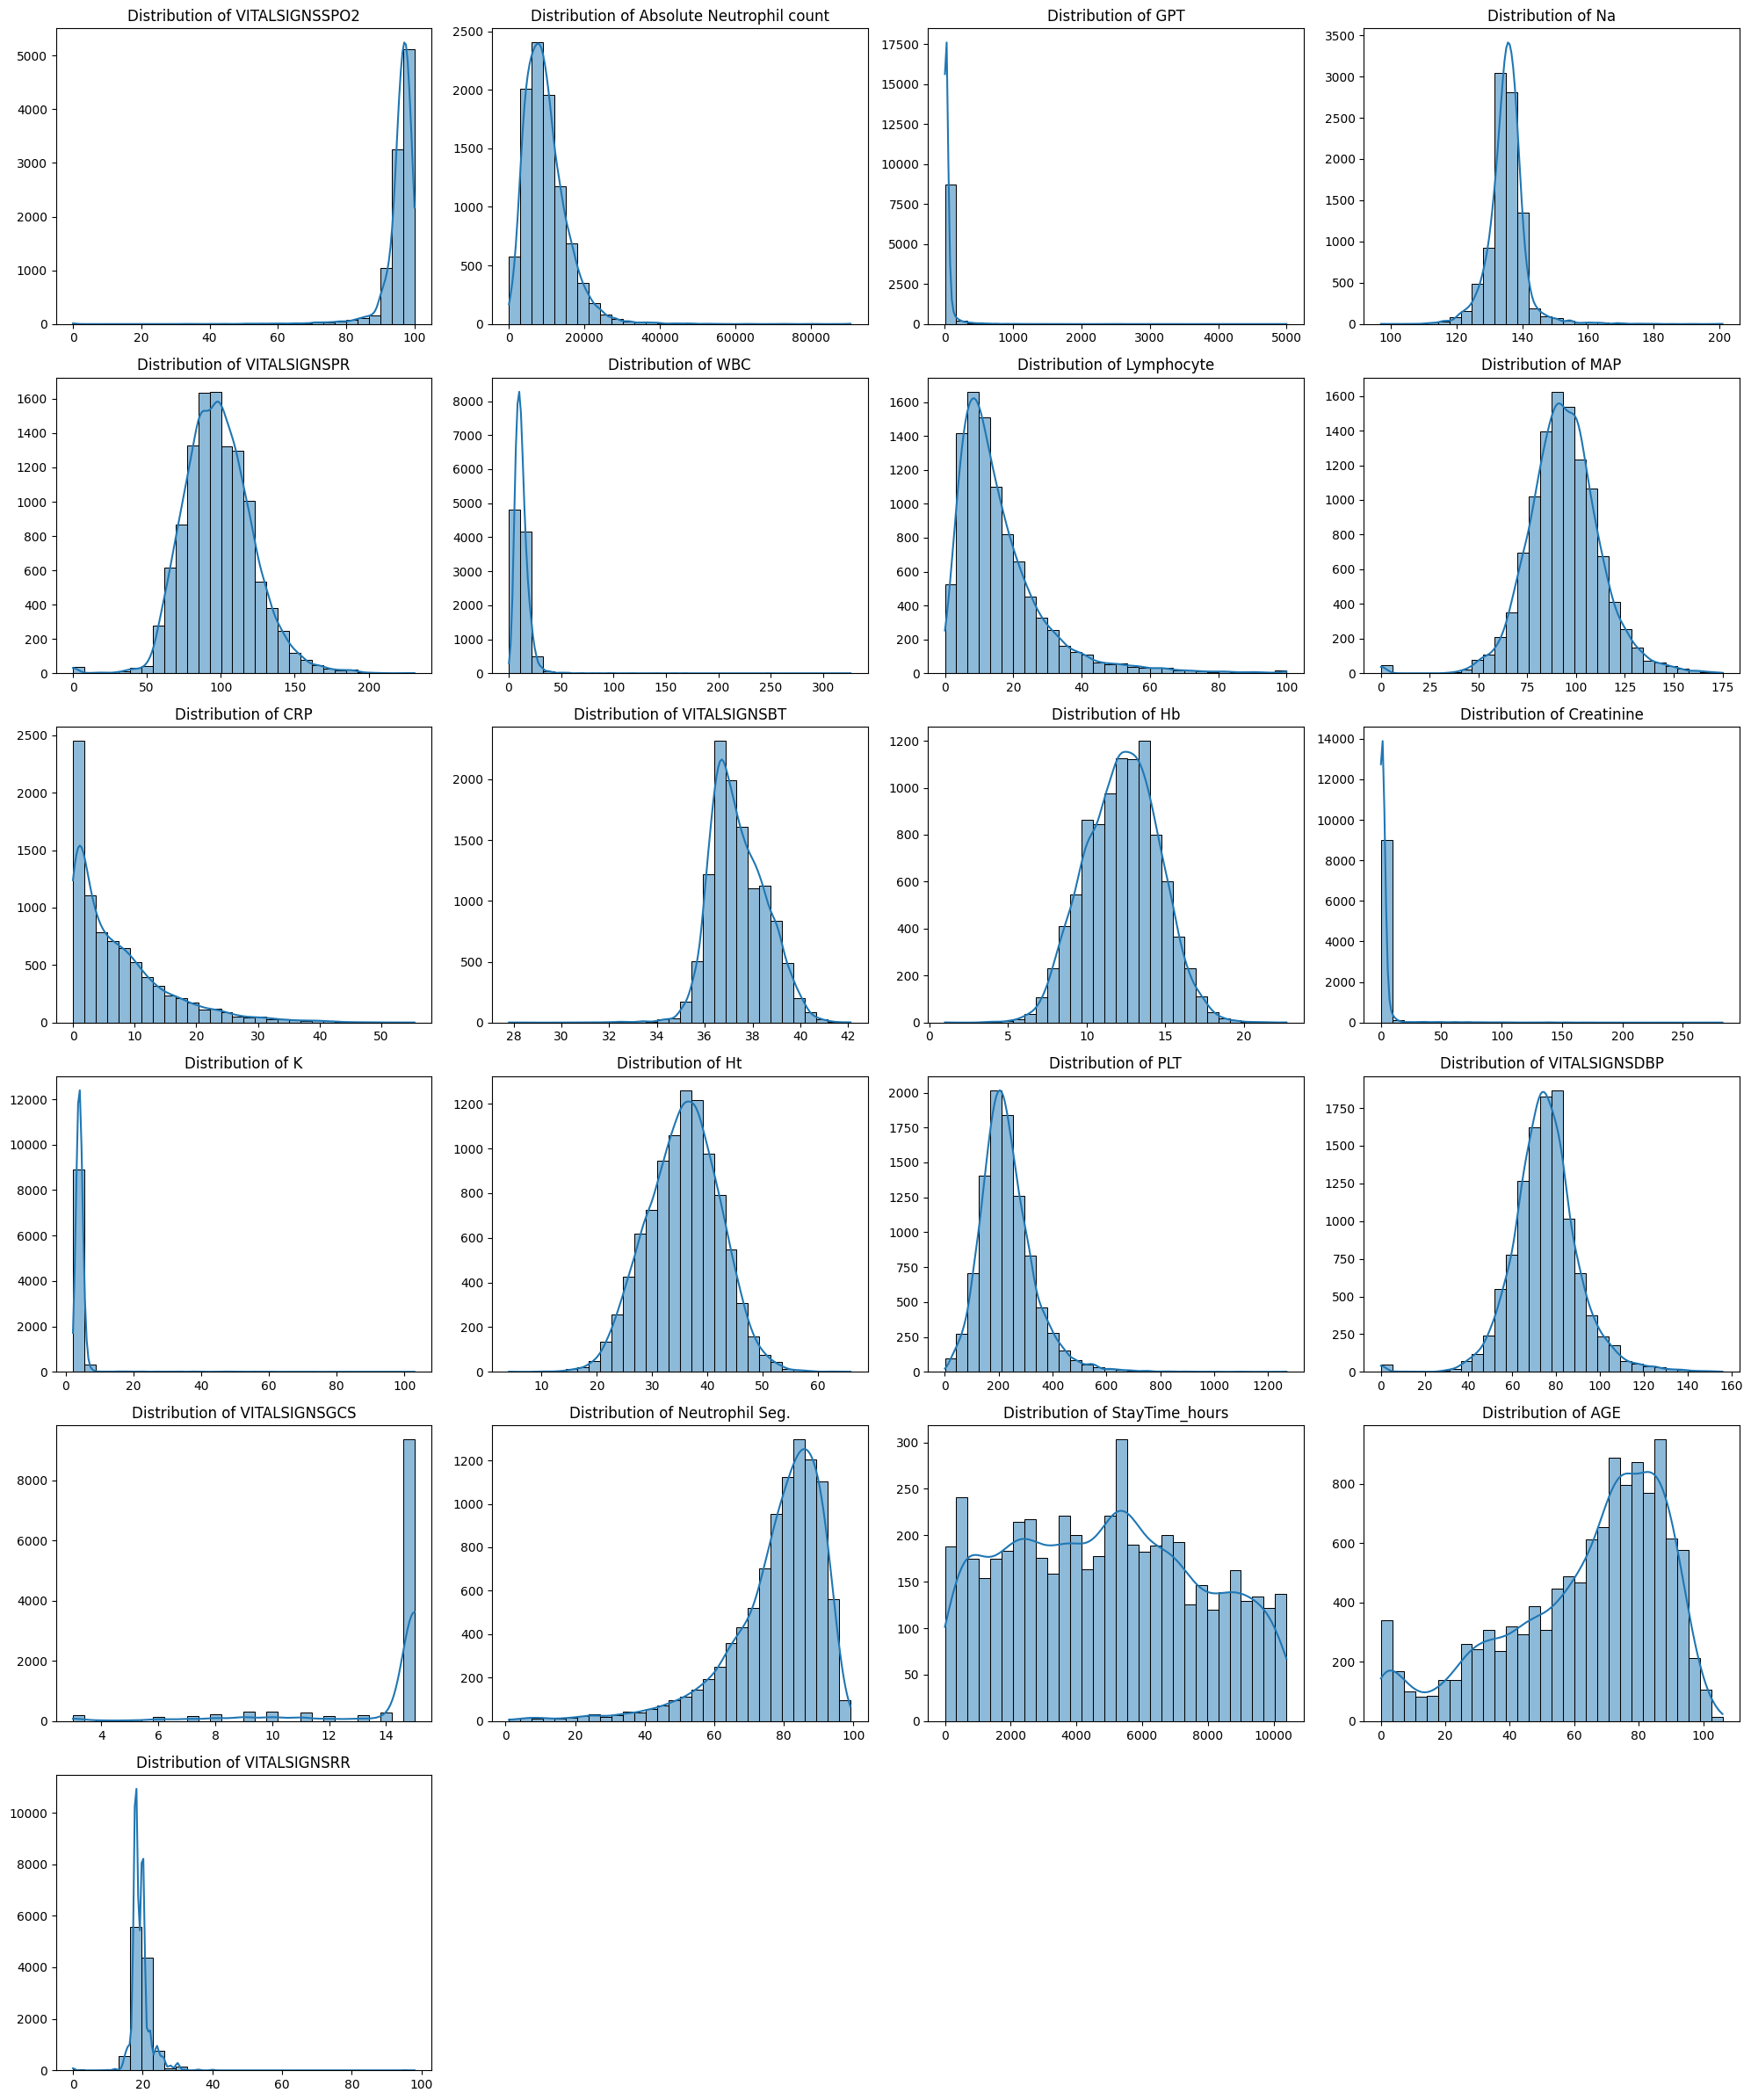

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

df = X

vital_cols = list(set(['AGE', 'StayTime_hours', 'VITALSIGNSBT', 'VITALSIGNSPR', 'VITALSIGNSRR', 'VITALSIGNSSPO2', 'VITALSIGNSDBP', 'VITALSIGNSGCS', 'MAP', 'Hb', 'WBC', 
            'Ht', 'PLT', 'Lymphocyte', 'Neutrophil Seg.', 'Absolute Neutrophil count', 'Na', 'K', 'Creatinine', 'GPT', 'CRP']))

# 設定每列顯示幾個圖
cols_per_row = 4
rows = math.ceil(len(vital_cols) / cols_per_row)

# 建立畫布
fig, axes = plt.subplots(rows, cols_per_row, figsize=(20, rows * 4))
axes = axes.flatten() # 將多維陣列拉平，方便迴圈讀取

for i, col in enumerate(vital_cols):
    if col in df.columns:
        # 繪製直方圖 + 密度曲線(kde)
        sns.histplot(df[col].dropna(), kde=True, ax=axes[i], bins=30)
        axes[i].set_title(f'Distribution of {col}', fontsize=12)
        axes[i].set_xlabel('')
        axes[i].set_ylabel('')
    else:
        axes[i].set_axis_off() # 如果欄位不存在就留白

# 移除多餘的空白子圖
for j in range(i + 1, len(axes)):
    axes[j].set_axis_off()

plt.tight_layout()
plt.show()

In [19]:
lower_bound = X.quantile(0.01)
upper_bound = X.quantile(0.99)

outliers_low = (X < lower_bound).sum()
outliers_high = (X > upper_bound).sum()

outlier_summary = pd.DataFrame({
    'Low_Outliers (<1%)': outliers_low,
    'High_Outliers (>99%)': outliers_high,
    'Total_Outliers': outliers_low + outliers_high
})

print(f"全資料集總離群值筆數: {outlier_summary['Total_Outliers'].sum()}")
print("\n各欄位離群值統計 (前 10 名):")
print(outlier_summary.sort_values('Total_Outliers', ascending=False).head(10))


全資料集總離群值筆數: 4051

各欄位離群值統計 (前 10 名):
                           Low_Outliers (<1%)  High_Outliers (>99%)  \
VITALSIGNSPR                              116                   115   
VITALSIGNSDBP                             102                   111   
MAP                                       101                   106   
VITALSIGNSBT                               91                   101   
Absolute Neutrophil count                  96                    96   
WBC                                        95                    96   
Ht                                         97                    92   
PLT                                        93                    95   
Lymphocyte                                 87                    96   
Hb                                         89                    91   

                           Total_Outliers  
VITALSIGNSPR                          231  
VITALSIGNSDBP                         213  
MAP                                   207  
VITAL

In [20]:
# outlier修改為1%或99% quantile
X = X.clip(lower=lower_bound, upper=upper_bound, axis=1)

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 123)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((9504, 85), (9504, 15), (2376, 85), (2376, 15))

In [22]:
X_train.isnull().sum(), X_test.isnull().sum()

(VITALSIGNSSPO2               1539
 Absolute Neutrophil count    1901
 CHECKITEM27SCORE             6339
 GPT                          2288
 Na                           2031
                              ... 
 CHECKITEM27_flag                0
 CHECKITEM27SCORE_flag           0
 CHECKITEM28SCORE_flag           0
 CHECKITEM31SCORE_flag           0
 CHECKITEM32SCORE_flag           0
 Length: 85, dtype: int64,
 VITALSIGNSSPO2                381
 Absolute Neutrophil count     453
 CHECKITEM27SCORE             1599
 GPT                           525
 Na                            478
                              ... 
 CHECKITEM27_flag                0
 CHECKITEM27SCORE_flag           0
 CHECKITEM28SCORE_flag           0
 CHECKITEM31SCORE_flag           0
 CHECKITEM32SCORE_flag           0
 Length: 85, dtype: int64)

In [23]:
X_train.dtypes, X_test.dtypes

(VITALSIGNSSPO2               float64
 Absolute Neutrophil count    float64
 CHECKITEM27SCORE             float64
 GPT                          float64
 Na                           float64
                               ...   
 CHECKITEM27_flag               int32
 CHECKITEM27SCORE_flag          int32
 CHECKITEM28SCORE_flag          int32
 CHECKITEM31SCORE_flag          int32
 CHECKITEM32SCORE_flag          int32
 Length: 85, dtype: object,
 VITALSIGNSSPO2               float64
 Absolute Neutrophil count    float64
 CHECKITEM27SCORE             float64
 GPT                          float64
 Na                           float64
                               ...   
 CHECKITEM27_flag               int32
 CHECKITEM27SCORE_flag          int32
 CHECKITEM28SCORE_flag          int32
 CHECKITEM31SCORE_flag          int32
 CHECKITEM32SCORE_flag          int32
 Length: 85, dtype: object)

In [24]:
y_train.sum().sort_values(ascending=False)

Flomoxef                       4157.0
Amoxicillin/Clavulanic acid    1255.0
Piperacillin/Tazobactam        1201.0
Cefoperazone/sulbactam         1125.0
Metronidazole                   737.0
Ciprofloxacin                   700.0
Cefixime                        695.0
Azithromycin                    560.0
Ceftriaxone                     496.0
Cefazolin                       467.0
Levofloxacin                    413.0
Cefuroxime                      399.0
Clindamycin                     289.0
Gentamicin                      158.0
Ampicillin                       73.0
dtype: float64

In [25]:
# 轉數值

num_cols = ['AGE', 'StayTime_hours', 'VITALSIGNSBT', 'VITALSIGNSPR', 'VITALSIGNSRR', 'VITALSIGNSSPO2', 'VITALSIGNSDBP', 'VITALSIGNSGCS', 'MAP', 'Hb', 'WBC', 
            'Ht', 'PLT', 'Lymphocyte', 'Neutrophil Seg.', 'Absolute Neutrophil count', 'Na', 'K', 'Creatinine', 'GPT', 'CRP']

for col in num_cols:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

In [26]:
# vital sign impute
vital_cols = ['AGE', 'StayTime_hours', 'VITALSIGNSBT', 'VITALSIGNSPR', 'VITALSIGNSRR', 'VITALSIGNSSPO2', 'VITALSIGNSDBP', 'VITALSIGNSGCS', 'MAP', 'Hb', 'WBC', 
              'Ht', 'PLT', 'Lymphocyte', 'Neutrophil Seg.', 'Absolute Neutrophil count', 'Na', 'K', 'Creatinine', 'GPT', 'CRP']


for col in vital_cols:
    # X_train[col + "_missing"] = X_train[col].isna().astype(int) # missing indicator
    median = X_train[col].median()
    X_train[col] = X_train[col].fillna(median)
    
    # X_test[col + "_missing"] = X_test[col].isna().astype(int) # missing indicator
    X_test[col] = X_test[col].fillna(median)

In [27]:
# 取 log

X_train['CRP'] = np.log1p(X_train['CRP'])
X_test['CRP'] = np.log1p(X_test['CRP'])

X_train['PLT'] = np.log1p(X_train['PLT'])
X_test['PLT'] = np.log1p(X_test['PLT'])

X_train['WBC'] = np.log1p(X_train['WBC'])
X_test['WBC'] = np.log1p(X_test['WBC'])

X_train['AGE'] = np.log1p(X_train['AGE'])
X_test['AGE'] = np.log1p(X_test['AGE'])

X_train['K'] = np.log1p(X_train['K'])
X_test['K'] = np.log1p(X_test['K'])

X_train['GPT'] = np.log1p(X_train['GPT'])
X_test['GPT'] = np.log1p(X_test['GPT'])

X_train['VITALSIGNSSPO2'] = np.log1p(X_train['VITALSIGNSSPO2'])
X_test['VITALSIGNSSPO2'] = np.log1p(X_test['VITALSIGNSSPO2'])

X_train['Absolute Neutrophil count'] = np.log1p(X_train['Absolute Neutrophil count'])
X_test['Absolute Neutrophil count'] = np.log1p(X_test['Absolute Neutrophil count'])

X_train['VITALSIGNSBT'] = np.log1p(X_train['VITALSIGNSBT'])
X_test['VITALSIGNSBT'] = np.log1p(X_test['VITALSIGNSBT'])

X_train['VITALSIGNSRR'] = np.log1p(X_train['VITALSIGNSRR'])
X_test['VITALSIGNSRR'] = np.log1p(X_test['VITALSIGNSRR'])

X_train['Creatinine'] = np.log1p(X_train['Creatinine'])
X_test['Creatinine'] = np.log1p(X_test['Creatinine'])

X_train['Na'] = np.log1p(X_train['Na'])
X_test['Na'] = np.log1p(X_test['Na'])

# X_train['Lymphocyte'] = np.log1p(X_train['Lymphocyte'])
# X_test['Lymphocyte'] = np.log1p(X_test['Lymphocyte'])

In [28]:
# fill score

score_cols = ['Leukocyte level_flag', 'Nitrite level_flag', 'Bacteria level_flag', 'Microscopic RBC level_flag', 'Microscopic WBC level_flag', 'PH_flag',
              'CHECKITEM29SCORE_flag', 'CHECKITEM30SCORE_flag', # 70~80% missing
              'HST_flag','T.Bilirubin_flag', 'PT_flag', 'HST_flag', 'INR_flag', 'APTT_flag', 'PCO2_flag', 'HCO3_flag', 'BE(ecf)_flag',
              'O2 SAT_flag', 'CHECKITEM28A_flag', 'CHECKITEM27_flag', 'CHECKITEM27SCORE_flag', 'CHECKITEM28SCORE_flag', 
              'CHECKITEM31SCORE_flag', 'CHECKITEM32SCORE_flag'] # > 80% missing

for col in score_cols:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_train[col] = X_train[col].fillna(-1)

    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')
    X_test[col] = X_test[col].fillna(-1)

In [29]:
y_train.sum(axis=1).mean() # 每人平均用1.24個抗生素

1.3389099326599327

In [30]:
drop_cols = ['HST', 'Leukocyte level' , 'Nitrite level', 'Bacteria level', 'Microscopic RBC level', 'Microscopic WBC level' , 
             'PH', 'T.Bilirubin', 'PT' , 'INR', 'APTT', 'PCO2' , 'HCO3', 'BE(ecf)', 'O2 SAT', 
             'CHECKITEM28A', 'CHECKITEM27', 'CHECKITEM27SCORE', 'CHECKITEM28SCORE', 'CHECKITEM29SCORE', 'CHECKITEM30SCORE', 
             'CHECKITEM31SCORE', 'CHECKITEM32SCORE']

X_train = X_train.drop(columns=drop_cols)
X_test = X_test.drop(columns=drop_cols)

In [31]:
scaled_cols = ['AGE', 'StayTime_hours', 'VITALSIGNSBT', 'VITALSIGNSPR', 'VITALSIGNSRR', 'VITALSIGNSSPO2', 'VITALSIGNSDBP', 'VITALSIGNSGCS', 'MAP', 'Hb', 'WBC', 
               'Ht', 'PLT', 'Lymphocyte', 'Neutrophil Seg.', 'Absolute Neutrophil count', 'Na', 'K', 'Creatinine', 'GPT', 'CRP']

scaler = StandardScaler()

X_train[scaled_cols] = scaler.fit_transform(X_train[scaled_cols])
X_test[scaled_cols] = scaler.fit_transform(X_test[scaled_cols])

In [32]:
X_train.shape
# X_train.to_csv('X_train_scale.csv')

(9504, 62)

In [33]:
y_train.columns

Index(['Amoxicillin/Clavulanic acid', 'Ampicillin', 'Azithromycin',
       'Cefazolin', 'Cefixime', 'Cefoperazone/sulbactam', 'Ceftriaxone',
       'Cefuroxime', 'Ciprofloxacin', 'Clindamycin', 'Flomoxef', 'Gentamicin',
       'Levofloxacin', 'Metronidazole', 'Piperacillin/Tazobactam'],
      dtype='object')

In [34]:
X_train.columns

Index(['VITALSIGNSSPO2', 'Absolute Neutrophil count', 'GPT', 'Na', 'LIVER',
       'VITALSIGNSPR', 'WBC', 'KIDNEY', 'Lymphocyte', 'CNS', 'INFECTIONSITE1',
       'MAP', 'CRP', 'VITALSIGNSBT', 'FEVER', 'AUTOIMMUNE', 'Hb', 'CANCER',
       'Creatinine', 'DM', 'K', 'INFECTIONSITE2', 'Ht',
       'OTHERINFECTIONSITE_flag', 'PLT', 'INFECTIONSITE9', 'CARDIOVASCULAR',
       'VITALSIGNSDBP', 'SEX', 'INFECTIONSITE4', 'VITALSIGNSGCS',
       'RESPIRATORY', 'INFECTIONSITE5', 'INFECTIONSITE3', 'Neutrophil Seg.',
       'StayTime_hours', 'AGE', 'INJURELEVEL', 'VITALSIGNSRR',
       'Leukocyte level_flag', 'Nitrite level_flag', 'Bacteria level_flag',
       'Microscopic RBC level_flag', 'Microscopic WBC level_flag', 'PH_flag',
       'CHECKITEM29SCORE_flag', 'CHECKITEM30SCORE_flag', 'HST_flag',
       'T.Bilirubin_flag', 'PT_flag', 'INR_flag', 'APTT_flag', 'PCO2_flag',
       'HCO3_flag', 'BE(ecf)_flag', 'O2 SAT_flag', 'CHECKITEM28A_flag',
       'CHECKITEM27_flag', 'CHECKITEM27SCORE_flag', 'CHECKI

In [35]:
# LogisticRegressionCV?
# XGBClassifier?
# RandomForestClassifier?
# MultiOutputClassifier.fit?

In [36]:
base_model = XGBClassifier(n_estimators=300,
                           max_depth=5,
                           learning_rate=0.05,
                           subsample=0.8,
                           colsample_bytree=0.8,
                           eval_metric='logloss',
                           gamma=0,
                           reg_alpha=2,
                           reg_lambda=0.0,
                           min_child_weight=1,
                           scale_pos_weight=3,
                           random_state =123,
                           n_jobs=-1
    )


multi_model = MultiOutputClassifier(base_model)
multi_model.fit(X_train, y_train) # sample_weight=sample_weight

#################################################################################################

# # 用字典存所有的子模型
# models = {}

# for col in y_train.columns:
#     # 針對每一種抗生素動態計算比例
#     pos = y_train[col].sum()
#     neg = len(y_train) - pos
#     spw = neg / pos if pos > 0 else 1
    
#     # 為該藥物建立專屬模型
#     model = XGBClassifier(
#                            n_estimators=300,
#                            max_depth=5,
#                            learning_rate=0.05,
#                            subsample=0.8,
#                            colsample_bytree=0.8,
#                            eval_metric='logloss',
#                            gamma=0,
#                            reg_alpha=2.0,
#                            reg_lambda=0.0,
#                            min_child_weight=1,
#                            scale_pos_weight=spw,
#                            random_state =123,
#                            n_jobs=-1
#     )
    
#     print(f"正在訓練 {col}, scale_pos_weight: {spw:.2f}")
#     model.fit(X_train, y_train[col])
#     models[col] = model

# # 預測時手動合併
# y_prob_list = np.column_stack([models[col].predict_proba(X_test)[:, 1] for col in y_train.columns])

,estimator,"XGBClassifier...ree=None, ...)"
,n_jobs,None
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None


In [37]:
y_pred_train = multi_model.predict(X_train)
print(f1_score(y_train, y_pred_train, average='micro'))
print(f1_score(y_train, y_pred_train, average='macro'))

0.8227701232777375
0.8746891079938909


In [79]:
# # # 原始機率
y_prob_list = np.column_stack([multi_model.predict_proba(X_test)[:, 1] for multi_model in multi_model.estimators_])
y_pred = multi_model.predict(X_test)
# print(y_pred[:5])

# 計算每種抗生素的使用頻率
drug_freq = y_train.mean(axis=0).values
drug_freq = np.clip(drug_freq, 1e-6, None) #避免除以0

# 計算每種抗生素權重(F1/recall)
drug_weight = []

for i, col in enumerate(y_train.columns):
    score = 1 / (f1_score(y_test.values[:, i], y_pred[:, i], average='binary') + 1e-6)
    drug_weight.append(score)
drug_weight = np.clip(drug_weight, 1e-6, None)

#  normalize
drug_weight = drug_weight / drug_weight.mean()

alpha = 0.01 # penalty
belta = 0.9

# adjusted_scores = y_prob_list / (drug_freq ** alpha)
# adjusted_scores = y_prob_list * drug_weight ** belta - alpha * np.log(drug_freq)
adjusted_scores = y_prob_list * drug_weight ** belta

# 用adjusted_scores排序
topk_idx = np.argsort(adjusted_scores, axis=1)[:, -3:]

In [80]:
drug_weight

array([0.25529758, 0.24829247, 0.85171118, 0.59405676, 3.37158463,
       0.78483029, 0.64131895, 2.6134595 , 0.68141773, 0.48912726,
       0.2813924 , 0.50514606, 2.63700385, 0.60450242, 0.44085892])

In [81]:
drug_weight ** belta

array([0.29264562, 0.28540869, 0.86549211, 0.62581382, 2.98573087,
       0.804078  , 0.67045042, 2.3740737 , 0.7080633 , 0.52538743,
       0.31943399, 0.54084806, 2.39331403, 0.63570882, 0.47848648])

In [82]:
print(f1_score(y_test, y_pred, average='micro'))
print(f1_score(y_test, y_pred, average='macro'))

0.5052805280528053
0.3473571766027102


In [83]:
jaccard_score(y_test, y_pred, average='samples', zero_division=0)

0.43643378226711554

In [84]:
hamming_loss(y_test, y_pred)

0.08411896745230078

In [89]:
for i in range(len(y_prob_list)):
    y_pred[i, topk_idx[i]] = 1

# top k hits rate

def hit_rate_at_k(y_true, proba, k=3):
    
    if isinstance(proba, list):
       proba = np.column_stack([p[:, 1] for p in proba])
    
    topk = np.argsort(proba, axis=1)[:, -k:]
    hits = 0
    for i in range(len(y_true)):
        actual = np.where(y_true[i]==1)[0]
        if len(set(actual)& set(topk[i].tolist())):
            hits += 1
    return hits /  len(y_true)

# precision@3
def precision_at_k(y_true, proba, k=3):
    # 處理 MultiOutputClassifier 的 proba 格式 (list of arrays)
    if isinstance(proba, list):
       proba = np.column_stack([p[:, 1] for p in proba])
    
    # 取得機率最高的前 k 個索引
    topk = np.argsort(proba, axis=1)[:, -k:]
    
    total_precision = 0
    for i in range(len(y_true)):
        # 該病患實際有開的藥物索引
        actual = set(np.where(y_true[i] == 1)[0])
        # 預測的前 k 個藥物索引
        predicted = set(topk[i].tolist())
        
        # 交集數量 (中了幾個) / 推薦數量 k
        hits = len(actual & predicted)
        total_precision += (hits / k)
        
    # 回傳所有樣本的平均 Precision@k
    return total_precision / len(y_true)

# recall@3

def recall_at_k(y_true, proba, k=3):
    if isinstance(proba, list):
        proba = np.column_stack([p[:, 1] for p in proba])

    topk = np.argsort(proba, axis=1)[:, -k:]
    hits = 0
    recalls = []
    for i in range(len(y_true)):
        actual = np.where(y_true[i]==1)[0]
        if len(actual) == 0:
            continue
        recall = len(set(actual) & set(topk[i])) / len(actual)
        recalls.append(recall)
    return np.mean(recalls)

# MAP@3

def map_at_k(y_true, scores, k=3):

    topk = np.argsort(scores, axis=1)[:, ::-1][:, :k]  # 排序

    APs = []

    for i in range(len(y_true)):
        actual = np.where(y_true[i] == 1)[0]

        if len(actual) == 0:
            continue

        hits = 0
        score = 0

        for j in range(k):
            if topk[i][j] in actual:
                hits += 1
                score += hits / (j + 1)

        APs.append(score / min(len(actual), k))

    return np.mean(APs)


################################

hit3 = hit_rate_at_k(y_test.values, adjusted_scores, k=5)
print('Hit@3: ', hit3)
precision3 = precision_at_k(y_test.values, adjusted_scores, k=5)
print('precision@3: ', precision3)
recall_3 = recall_at_k(y_test.values, adjusted_scores, k=5)
print('Recall@3: ', recall_3)
map_3 = map_at_k(y_test.values, adjusted_scores, k=5)
print('MAP@3: ', map_3)

Hit@3:  0.8695286195286195
precision@3:  0.22213804713804114
Recall@3:  0.8480989696705848
MAP@3:  0.5029101968751511


In [93]:
drug_names = y_train.columns


def show_top3_prediction(patient_idx, proba_matrix, y_true, drug_names, k=3):
    #預測
    probs = proba_matrix[patient_idx]
    topk_idx = np.argsort(probs)[-k:][::-1]

    #實際
    actual_idx = np.where(y_true[patient_idx] == 1)[0]
    actual_drugs = drug_names[actual_idx].tolist()

    print(f"實際給藥: {actual_drugs if actual_drugs else '無'}")
    print("\n推薦藥物:")
    for rank, idx in enumerate(topk_idx, 1):
        print(f"{rank}. {drug_names[idx]} (Score: {probs[idx]:.4f})")
    print("="*50)

for i in range(10):
    show_top3_prediction(i, adjusted_scores, y_test.values, drug_names, k=10)

實際給藥: ['Ciprofloxacin', 'Flomoxef', 'Metronidazole']

推薦藥物:
1. Cefuroxime (Score: 1.4419)
2. Cefixime (Score: 0.6326)
3. Flomoxef (Score: 0.2745)
4. Cefazolin (Score: 0.1243)
5. Metronidazole (Score: 0.0981)
6. Ciprofloxacin (Score: 0.0969)
7. Cefoperazone/sulbactam (Score: 0.0548)
8. Piperacillin/Tazobactam (Score: 0.0321)
9. Azithromycin (Score: 0.0321)
10. Ceftriaxone (Score: 0.0252)
實際給藥: ['Piperacillin/Tazobactam']

推薦藥物:
1. Piperacillin/Tazobactam (Score: 0.3267)
2. Cefoperazone/sulbactam (Score: 0.3026)
3. Flomoxef (Score: 0.1727)
4. Azithromycin (Score: 0.1399)
5. Metronidazole (Score: 0.0642)
6. Ciprofloxacin (Score: 0.0492)
7. Levofloxacin (Score: 0.0405)
8. Cefixime (Score: 0.0273)
9. Ceftriaxone (Score: 0.0163)
10. Cefuroxime (Score: 0.0097)
實際給藥: ['Flomoxef', 'Metronidazole']

推薦藥物:
1. Metronidazole (Score: 0.3883)
2. Flomoxef (Score: 0.2789)
3. Cefixime (Score: 0.1875)
4. Ceftriaxone (Score: 0.1497)
5. Ciprofloxacin (Score: 0.1022)
6. Piperacillin/Tazobactam (Score: 0.098

In [95]:
importance_all = []

for i, drug in enumerate(y_train.columns):
    
    model = multi_model.estimators_[i]
    
    # 建立 Series 並與特徵名稱對應
    imp = pd.Series(
        model.feature_importances_,
        index=X_train.columns
    )

    imp_df = imp.reset_index()
    imp_df.columns = ['feature','importance']
    # imp_df['drug'] = drug
    
    imp_df_sorted = imp_df.sort_values("importance", ascending=False)
    
    print(f"=== Drug: {drug} (Top 20 Features) ===")
    print(imp_df_sorted.head(20).to_string(index=False)) # 不印索引比較美觀
    print('\n')
    print(f"Top 20 importance sum: {imp_df_sorted.head(20)['importance'].sum().round(3)}")
    print("-" * 40)
    
    importance_all.append(imp_df_sorted)

importance_all = pd.concat(importance_all)

=== Drug: Amoxicillin/Clavulanic acid (Top 20 Features) ===
                feature  importance
         INFECTIONSITE5    0.150814
    Bacteria level_flag    0.077314
         INFECTIONSITE2    0.068931
         INFECTIONSITE3    0.062964
                    AGE    0.050772
         INFECTIONSITE1    0.040717
              HCO3_flag    0.028409
              PCO2_flag    0.024491
       T.Bilirubin_flag    0.023050
         INFECTIONSITE9    0.022208
           BE(ecf)_flag    0.021299
              APTT_flag    0.020036
     Nitrite level_flag    0.019335
  CHECKITEM30SCORE_flag    0.018690
            INJURELEVEL    0.017986
            O2 SAT_flag    0.016745
   Leukocyte level_flag    0.014870
                PT_flag    0.014738
  CHECKITEM28SCORE_flag    0.013788
OTHERINFECTIONSITE_flag    0.012824


Top 20 importance sum: 0.7200000286102295
----------------------------------------
=== Drug: Ampicillin (Top 20 Features) ===
             feature  importance
                 AGE   

In [87]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# 挑選你想診斷的藥物
target_drug = 'Levofloxacin' #  , 'Cephalexin', 'Cefadroxil'

# 計算 MI
# discrete_features: 如果你的特徵有類別型（如部位），要標註 True
mi_scores = mutual_info_classif(X_train, y_train[target_drug], discrete_features='auto', random_state=123)

# 整理成 DataFrame
mi_df = pd.DataFrame({'feature': X_train.columns, 'mi_score': mi_scores})
mi_df = mi_df.sort_values(by='mi_score', ascending=False)

print(f"=== {target_drug} 的特徵資訊量排行 ===")
print(mi_df.head(10))

=== Levofloxacin 的特徵資訊量排行 ===
                  feature  mi_score
21         INFECTIONSITE2  0.014620
10         INFECTIONSITE1  0.011463
56      CHECKITEM28A_flag  0.008330
58  CHECKITEM27SCORE_flag  0.006540
61  CHECKITEM32SCORE_flag  0.006224
59  CHECKITEM28SCORE_flag  0.006137
46  CHECKITEM30SCORE_flag  0.005586
44                PH_flag  0.005518
45  CHECKITEM29SCORE_flag  0.005358
57       CHECKITEM27_flag  0.004038
